<a href="hhttps://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab2/L2_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2.3 Time and frequency domain calculations and analysis using ADXL345 data



For this section of Lab 2, have ready in hand all CSV files (highest rate outcome of 3200 Hz) from each activity: no fan, fan in normal condition, and  fan in anomalous condition.

For this portion of the lab, you will no longer need to use the Raspberry PI as you already have the data collected.

**You will run all your code using this Colab notebook**

## 3.1 Signal Processing and plotting data from: Fan off data

### Reading a CSV file and plotting data

In this part, we will read the saved CSV file generated in Lab 2.2 and then plot the data. A sample code structure is given below. It includes frequency domain transformations as well. However, the plotting part of the FFT signals is incomplete. You should finish the incomplete part.

Please note that you must change the ‘filename’ variable according to the CSV file you saved in the previous part. By modifying and adding lines, try to calculate time domain features from each axis data in Table 1 in the Prelab 2.2, such as mean, standard deviation, root mean square, and so on.






Import essential libraries:

In [1]:
import matplotlib
#matplotlib.use('tkagg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import io
import seaborn as sns
import csv

The following code allows you to upload the data stored in a csv file to this Colab notebook.

In [10]:
#This code allows you to upload a file from your local drive
from google.colab import files
uploaded = files.upload()
#If you will work with excel, please save your file with a .CSV format
#Check the output file name below. You will use that file name in the next block.

Saving fan_off.csv to fan_off.csv


The next coding block extracts information from the csv file, and saves it through arrays.
The FFT fourier code is incomplete (a_y, and a_z are not coded). Please finish coding it and plot it by uncommenting the plot code lines.

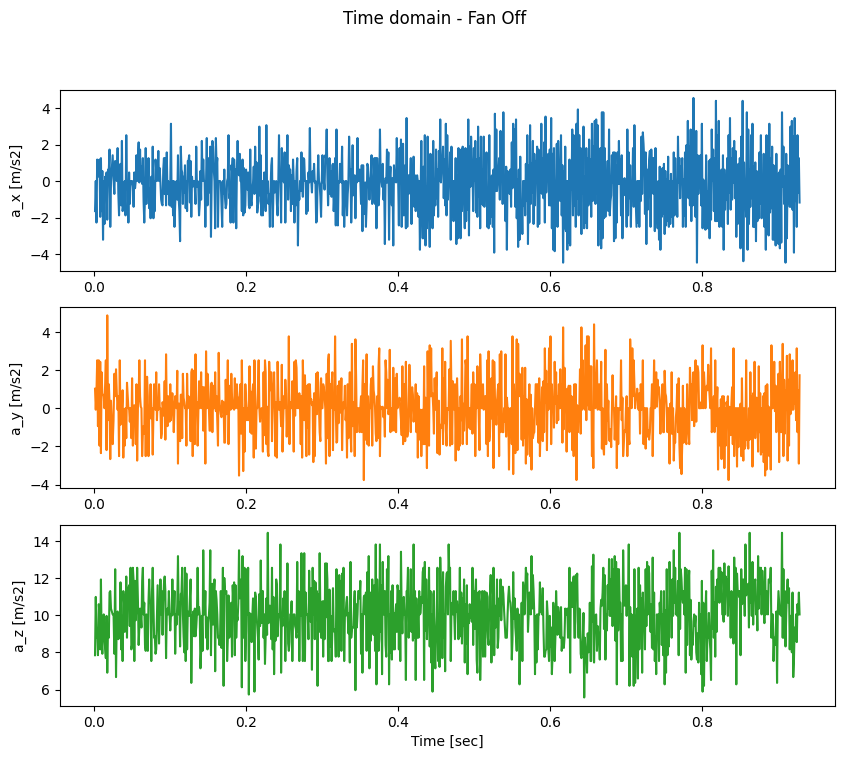

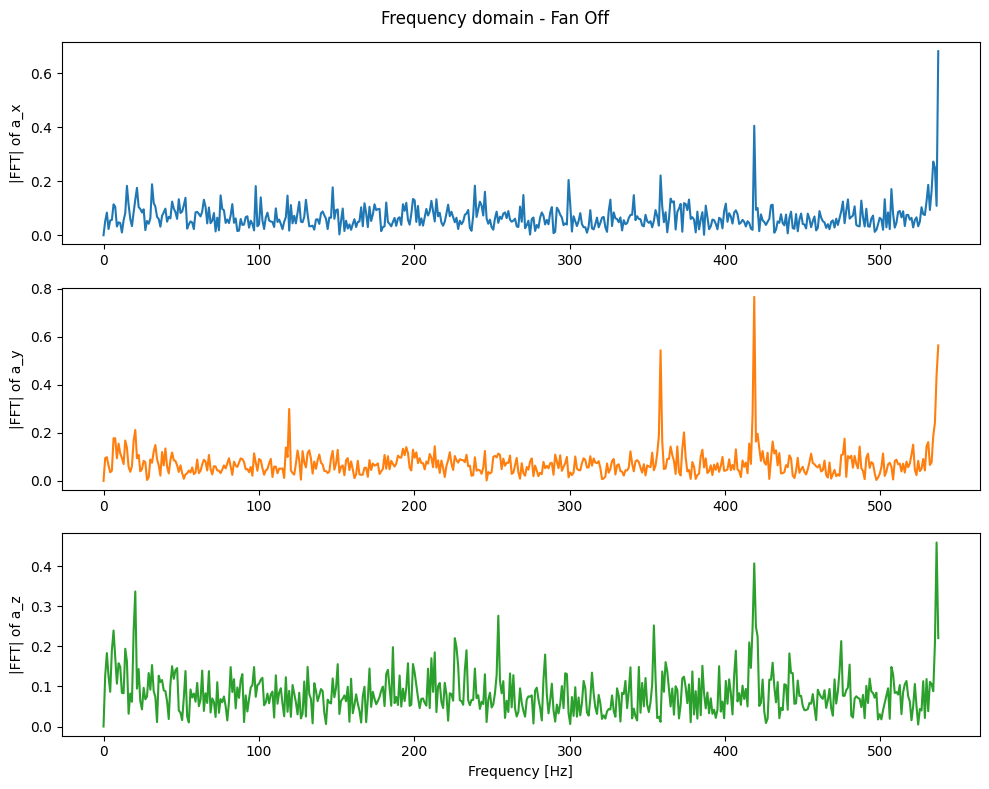

In [11]:
# 3.1 블록에 들어갈 완성본 코드
from pandas.core.internals.construction import dict_to_mgr
from scipy.fft import fft, fftfreq
import numpy as np
import matplotlib.pyplot as plt
import csv

# [필독] 업로드한 실제 csv 파일명으로 변경하세요
filename1 = 'helloworld1 (1).csv'

dt = []; t = []; a_x = []; a_y = []; a_z = []

with open(filename1, 'r') as f:
    rows = csv.reader(f, delimiter = ',')
    header = next(rows)
    for row in rows:
        dt.append(float(row[0]))
        t.append(float(row[1]))
        a_x.append(float(row[2]))
        a_y.append(float(row[3]))
        a_z.append(float(row[4]))

N = int(len(dt))
T = t[-1]/N

n = np.array(range(len(dt))) + 1
dt = np.array(dt)
t = np.array(t)
a_x = np.array(a_x)
a_y = np.array(a_y)
a_z = np.array(a_z)

# 시간 도메인 그래프 그리기
fig1, ax1 = plt.subplots(3, figsize=(10, 8))
fig1.suptitle('Time domain - Fan Off')
ax1[0].plot(t, a_x, 'tab:blue')
ax1[0].set_ylabel('a_x [m/s2]')
ax1[1].plot(t, a_y, 'tab:orange')
ax1[1].set_ylabel('a_y [m/s2]')
ax1[2].plot(t, a_z, 'tab:green')
ax1[2].set_ylabel('a_z [m/s2]')
ax1[2].set_xlabel('Time [sec]')

# FFT 함수 정의
def get_fft(x, T, N):
    f = fftfreq(N, T)[:N//2]
    y_mag = 2/N * np.abs(fft(x)[:N//2])
    y_mag[0] = 0
    return f, y_mag

# [빈칸 채우기] x, y, z축 모두 FFT 수행
f_x, y_x = get_fft(a_x, T, N)
f_y, y_y = get_fft(a_y, T, N)  # 완성 부분
f_z, y_z = get_fft(a_z, T, N)  # 완성 부분

# 주파수 도메인 그래프 그리기 (주석 해제 및 완성)
fig2, ax2 = plt.subplots(3, figsize=(10, 8))
fig2.suptitle('Frequency domain - Fan Off')
ax2[0].plot(f_x, y_x, 'tab:blue')
ax2[0].set_ylabel('|FFT| of a_x')
ax2[1].plot(f_y, y_y, 'tab:orange')  # 주석 해제
ax2[1].set_ylabel('|FFT| of a_y')  # 주석 해제
ax2[2].plot(f_z, y_z, 'tab:green')   # 주석 해제
ax2[2].set_ylabel('|FFT| of a_z')   # 주석 해제
ax2[2].set_xlabel('Frequency [Hz]')

plt.tight_layout()
plt.show()

## 3.2 Signal Processing and plotting data from: Fan normal condition data

Reuse the code above to process the data and plot the signal for fan data in normal conditions.

HINT: Do not use the same variables names from code above. You will need all data information stored in different variables for Section 3.4

In [12]:
#Insert the block of code to upload the csv file here:
# Insert the block of code to upload the csv file here:
from google.colab import files
import csv
import numpy as np

# 1. 파일 업로드 창 실행
print("--- 정상 상태(Normal) CSV 파일을 업로드하세요 ---")
uploaded_norm = files.upload()

# 2. 파일명 가져오기 (업로드한 첫 번째 파일 자동 매칭)
filename_norm = list(uploaded_norm.keys())[0]
print(f"Loaded file: {filename_norm}")

# 3. 데이터 리스트 초기화
dt_norm = []
t_norm = []
a_x_norm = []
a_y_norm = []
a_z_norm = []

# 4. CSV 데이터 읽기
with open(filename_norm, 'r') as f:
    rows = csv.reader(f, delimiter=',')
    header = next(rows)
    for row in rows:
        dt_norm.append(float(row[0]))
        t_norm.append(float(row[1]))
        a_x_norm.append(float(row[2]))
        a_y_norm.append(float(row[3]))
        a_z_norm.append(float(row[4]))

# 5. 넘파이 배열 변환 및 파라미터 계산
N_norm = int(len(dt_norm))
T_norm = t_norm[-1] / N_norm

dt_norm = np.array(dt_norm)
t_norm = np.array(t_norm)
a_x_norm = np.array(a_x_norm)
a_y_norm = np.array(a_y_norm)
a_z_norm = np.array(a_z_norm)

print(f"Successfully loaded {N_norm} samples for normal condition.")

--- 정상 상태(Normal) CSV 파일을 업로드하세요 ---


Saving fan_normal.csv to fan_normal.csv
Loaded file: fan_normal.csv
Successfully loaded 1000 samples for normal condition.


In [13]:
#Insert the block of code for calculating time-domain features:
#Print out all time domain features in this block
# Insert the block of code for calculating time-domain features:
# Print out all time domain features in this block
from scipy.stats import skew, kurtosis

def calculate_and_print_features(axis_name, data):
    m = np.mean(data)
    std = np.std(data, ddof=1)
    rms = np.sqrt(np.mean(data**2))
    peak = np.max(np.abs(data))
    sk = skew(data)
    kt = kurtosis(data)
    cf = peak / rms

    print(f"[{axis_name} Features - Normal]")
    print(f" 1. Mean               = {m:.6f}")
    print(f" 2. Standard Deviation = {std:.6f}")
    print(f" 3. Root Mean Square   = {rms:.6f}")
    print(f" 4. Peak               = {peak:.6f}")
    print(f" 5. Skewness           = {sk:.6f}")
    print(f" 6. Kurtosis           = {kt:.6f}")
    print(f" 7. Crest Factor       = {cf:.6f}")
    print("-" * 40)

# X, Y, Z축 각각 특징값 계산 및 출력
calculate_and_print_features("a_x_norm", a_x_norm)
calculate_and_print_features("a_y_norm", a_y_norm)
calculate_and_print_features("a_z_norm", a_z_norm)

[a_x_norm Features - Normal]
 1. Mean               = -0.169459
 2. Standard Deviation = 1.739702
 3. Root Mean Square   = 1.747070
 4. Peak               = 4.550286
 5. Skewness           = 0.008487
 6. Kurtosis           = -0.509293
 7. Crest Factor       = 2.604524
----------------------------------------
[a_y_norm Features - Normal]
 1. Mean               = 0.054368
 2. Standard Deviation = 1.576840
 3. Root Mean Square   = 1.576989
 4. Peak               = 4.864098
 5. Skewness           = 0.048750
 6. Kurtosis           = -0.312468
 7. Crest Factor       = 3.084421
----------------------------------------
[a_z_norm Features - Normal]
 1. Mean               = 10.028751
 2. Standard Deviation = 1.714866
 3. Root Mean Square   = 10.174167
 4. Peak               = 14.435389
 5. Skewness           = -0.084959
 6. Kurtosis           = -0.453775
 7. Crest Factor       = 1.418828
----------------------------------------


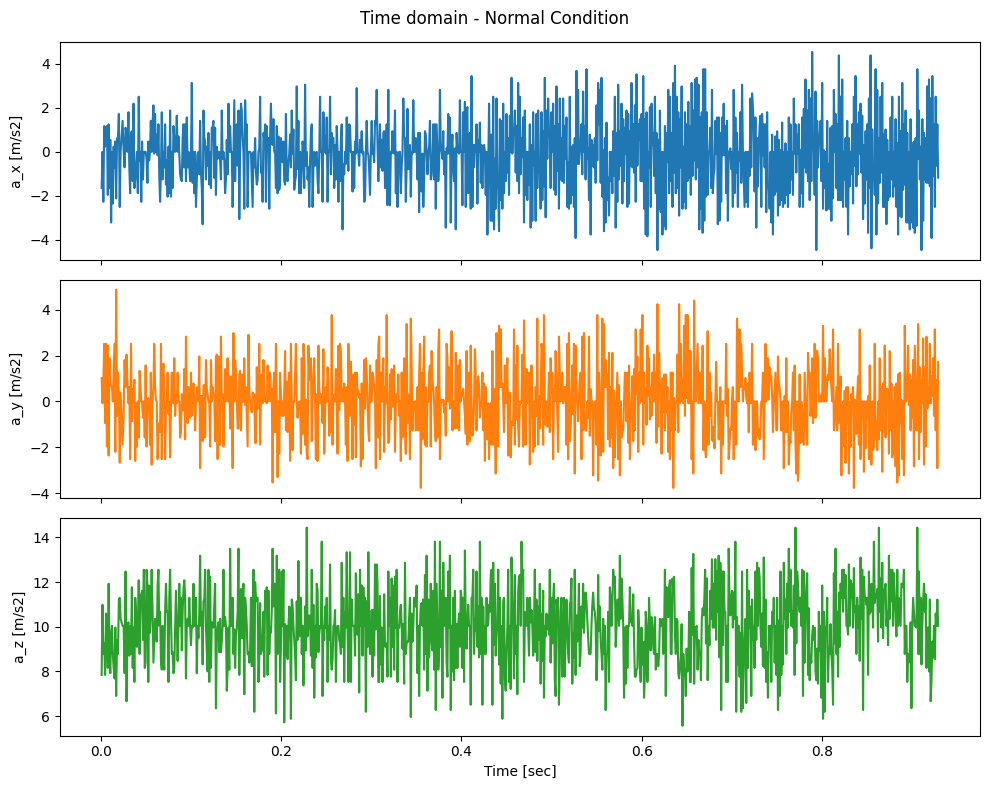

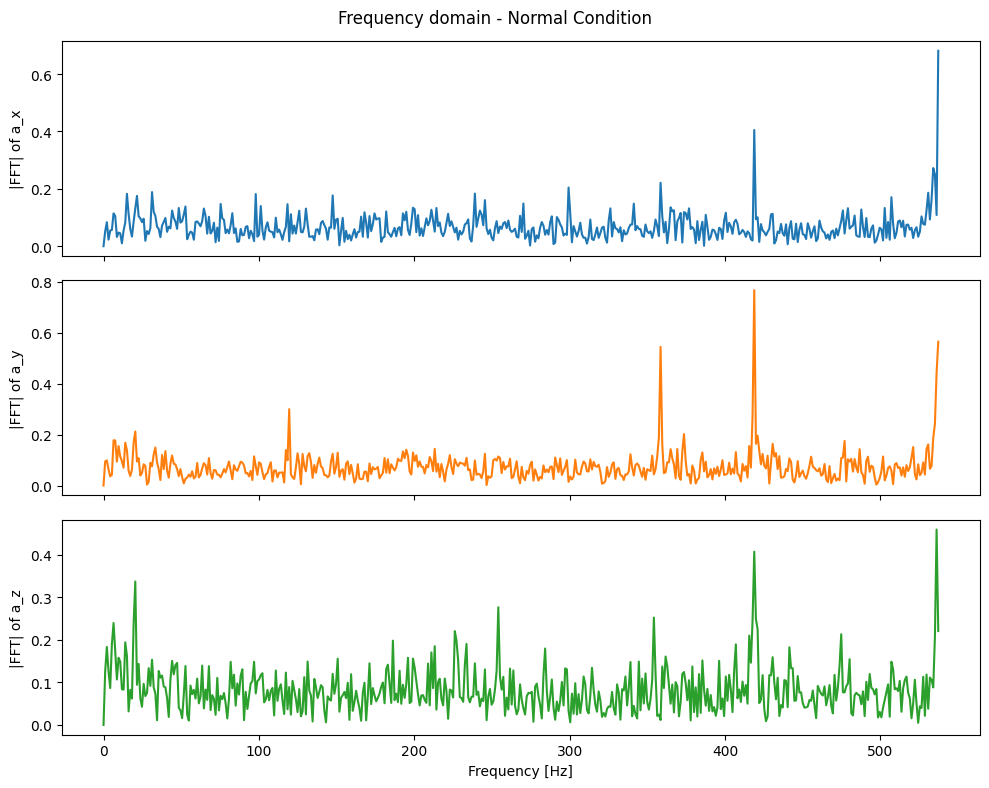

In [14]:
#Insert the block of code for processing and plotting here:
# Insert the block of code for processing and plotting here:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# 1. FFT 함수 정의
def get_fft_norm(x, T, N):
    f = fftfreq(N, T)[:N//2]
    y_mag = 2/N * np.abs(fft(x)[:N//2])
    y_mag[0] = 0
    return f, y_mag

# 2. X, Y, Z축 FFT 수행
f_x_norm, y_x_norm = get_fft_norm(a_x_norm, T_norm, N_norm)
f_y_norm, y_y_norm = get_fft_norm(a_y_norm, T_norm, N_norm)
f_z_norm, y_z_norm = get_fft_norm(a_z_norm, T_norm, N_norm)

# 3. 시간 영역(Time Domain) 그래프 그리기
fig1, ax1 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig1.suptitle('Time domain - Normal Condition')
ax1[0].plot(t_norm, a_x_norm, 'tab:blue')
ax1[0].set_ylabel('a_x [m/s2]')
ax1[1].plot(t_norm, a_y_norm, 'tab:orange')
ax1[1].set_ylabel('a_y [m/s2]')
ax1[2].plot(t_norm, a_z_norm, 'tab:green')
ax1[2].set_ylabel('a_z [m/s2]')
ax1[2].set_xlabel('Time [sec]')
plt.tight_layout()
plt.show()

# 4. 주파수 영역(Frequency Domain) 그래프 그리기
fig2, ax2 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig2.suptitle('Frequency domain - Normal Condition')
ax2[0].plot(f_x_norm, y_x_norm, 'tab:blue')
ax2[0].set_ylabel('|FFT| of a_x')
ax2[1].plot(f_y_norm, y_y_norm, 'tab:orange')
ax2[1].set_ylabel('|FFT| of a_y')
ax2[2].plot(f_z_norm, y_z_norm, 'tab:green')
ax2[2].set_ylabel('|FFT| of a_z')
ax2[2].set_xlabel('Frequency [Hz]')
plt.tight_layout()
plt.show()

## 3.3 Signal Processing and plotting data from: Fan anomalous condition data

Reuse the code above to process the data and plot the signal for fan data in normal conditions.

HINT: Do not use the same variables names from code above. You will need all data information stored in different variables for Section 3.4

In [15]:
#Insert the block of code to upload the csv file here:
# Insert the block of code to upload the csv file here:
from google.colab import files
import csv
import numpy as np

# 1. 파일 업로드 창 실행
print("--- 이상 상태(Anomalous) CSV 파일을 업로드하세요 ---")
uploaded_anom = files.upload()

# 2. 파일명 가져오기 (업로드한 첫 번째 파일 자동 매칭)
filename_anom = list(uploaded_anom.keys())[0]
print(f"Loaded file: {filename_anom}")

# 3. 데이터 리스트 초기화
dt_anom = []
t_anom = []
a_x_anom = []
a_y_anom = []
a_z_anom = []

# 4. CSV 데이터 읽기
with open(filename_anom, 'r') as f:
    rows = csv.reader(f, delimiter=',')
    header = next(rows)
    for row in rows:
        dt_anom.append(float(row[0]))
        t_anom.append(float(row[1]))
        a_x_anom.append(float(row[2]))
        a_y_anom.append(float(row[3]))
        a_z_anom.append(float(row[4]))

# 5. 넘파이 배열 변환 및 파라미터 계산
N_anom = int(len(dt_anom))
T_anom = t_anom[-1] / N_anom

dt_anom = np.array(dt_anom)
t_anom = np.array(t_anom)
a_x_anom = np.array(a_x_anom)
a_y_anom = np.array(a_y_anom)
a_z_anom = np.array(a_z_anom)

print(f"Successfully loaded {N_anom} samples for anomalous condition.")

--- 이상 상태(Anomalous) CSV 파일을 업로드하세요 ---


Saving fan_abnormal.csv to fan_abnormal.csv
Loaded file: fan_abnormal.csv
Successfully loaded 1000 samples for anomalous condition.


In [17]:
#Insert the block of code for calculating time-domain features:
#Print out all time domain features in this block
# Insert the block of code for calculating time-domain features:
# Print out all time domain features in this block
from scipy.stats import skew, kurtosis

def calculate_and_print_features_anom(axis_name, data):
    m = np.mean(data)
    std = np.std(data, ddof=1)
    rms = np.sqrt(np.mean(data**2))
    peak = np.max(np.abs(data))
    sk = skew(data)
    kt = kurtosis(data)
    cf = peak / rms

    print(f"[{axis_name} Features - Anomalous]")
    print(f" 1. Mean               = {m:.6f}")
    print(f" 2. Standard Deviation = {std:.6f}")
    print(f" 3. Root Mean Square   = {rms:.6f}")
    print(f" 4. Peak               = {peak:.6f}")
    print(f" 5. Skewness           = {sk:.6f}")
    print(f" 6. Kurtosis           = {kt:.6f}")
    print(f" 7. Crest Factor       = {cf:.6f}")
    print("-" * 40)

# X, Y, Z축 각각 특징값 계산 및 출력
calculate_and_print_features_anom("a_x_anom", a_x_anom)
calculate_and_print_features_anom("a_y_anom", a_y_anom)
calculate_and_print_features_anom("a_z_anom", a_z_anom)

[a_x_anom Features - Anomalous]
 1. Mean               = -0.249873
 2. Standard Deviation = 3.595020
 3. Root Mean Square   = 3.601900
 4. Peak               = 20.084019
 5. Skewness           = -0.356190
 6. Kurtosis           = 6.632910
 7. Crest Factor       = 5.575951
----------------------------------------
[a_y_anom Features - Anomalous]
 1. Mean               = 0.147570
 2. Standard Deviation = 1.799811
 3. Root Mean Square   = 1.804954
 4. Peak               = 10.355822
 5. Skewness           = -0.355506
 6. Kurtosis           = 1.936539
 7. Crest Factor       = 5.737444
----------------------------------------
[a_z_anom Features - Anomalous]
 1. Mean               = 9.956613
 2. Standard Deviation = 2.553627
 3. Root Mean Square   = 10.278552
 4. Peak               = 20.044793
 5. Skewness           = 0.143828
 6. Kurtosis           = 1.943437
 7. Crest Factor       = 1.950157
----------------------------------------


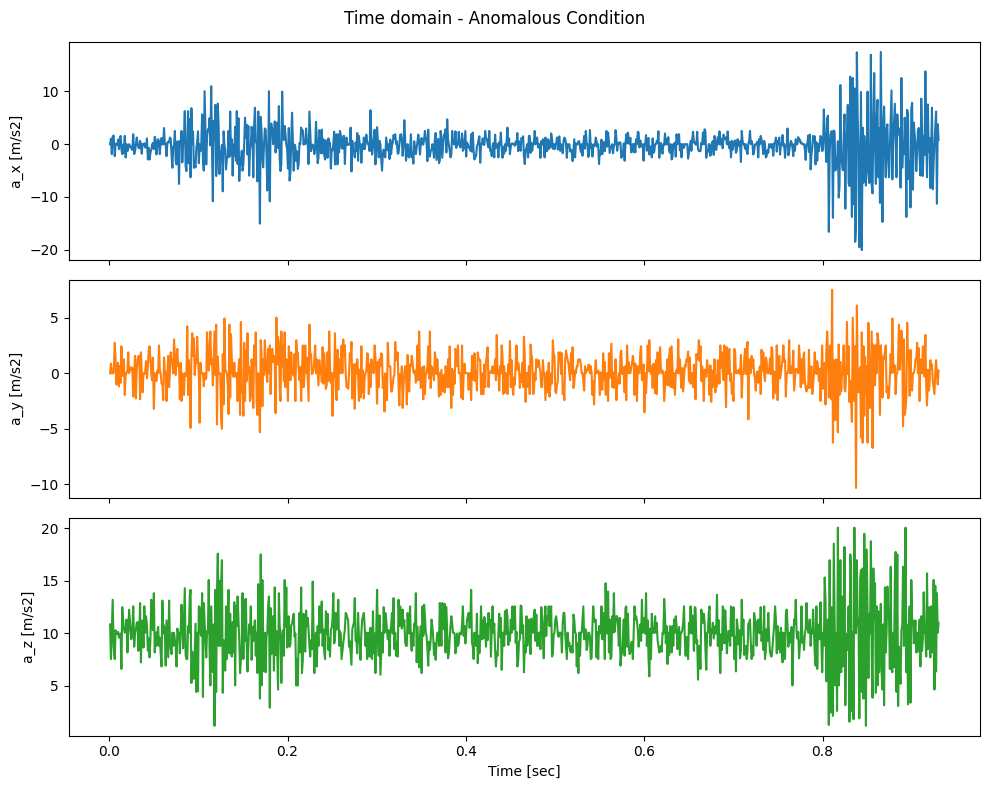

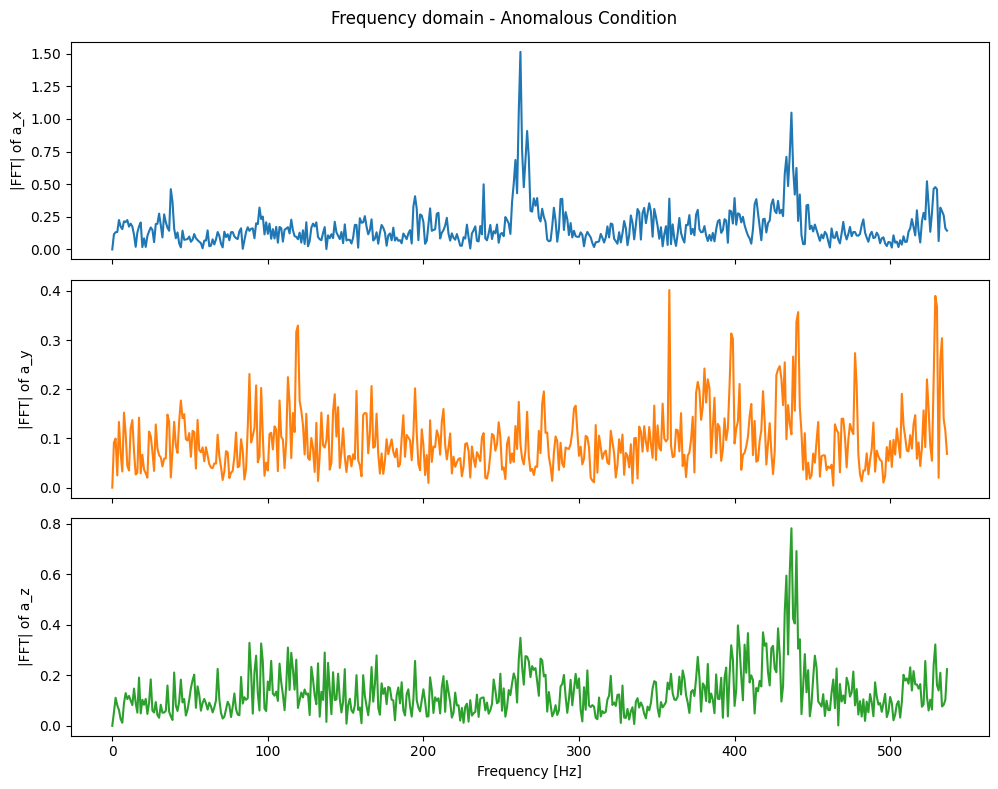

In [16]:
#Insert the block of code for processing and plotting here:
# Insert the block of code for processing and plotting here:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# 1. FFT 함수 정의
def get_fft_anom(x, T, N):
    f = fftfreq(N, T)[:N//2]
    y_mag = 2/N * np.abs(fft(x)[:N//2])
    y_mag[0] = 0
    return f, y_mag

# 2. X, Y, Z축 FFT 수행
f_x_anom, y_x_anom = get_fft_anom(a_x_anom, T_anom, N_anom)
f_y_anom, y_y_anom = get_fft_anom(a_y_anom, T_anom, N_anom)
f_z_anom, y_z_anom = get_fft_anom(a_z_anom, T_anom, N_anom)

# 3. 시간 영역(Time Domain) 그래프 그리기
fig1, ax1 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig1.suptitle('Time domain - Anomalous Condition')
ax1[0].plot(t_anom, a_x_anom, 'tab:blue')
ax1[0].set_ylabel('a_x [m/s2]')
ax1[1].plot(t_anom, a_y_anom, 'tab:orange')
ax1[1].set_ylabel('a_y [m/s2]')
ax1[2].plot(t_anom, a_z_anom, 'tab:green')
ax1[2].set_ylabel('a_z [m/s2]')
ax1[2].set_xlabel('Time [sec]')
plt.tight_layout()
plt.show()

# 4. 주파수 영역(Frequency Domain) 그래프 그리기
fig2, ax2 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig2.suptitle('Frequency domain - Anomalous Condition')
ax2[0].plot(f_x_anom, y_x_anom, 'tab:blue')
ax2[0].set_ylabel('|FFT| of a_x')
ax2[1].plot(f_y_anom, y_y_anom, 'tab:orange')
ax2[1].set_ylabel('|FFT| of a_y')
ax2[2].plot(f_z_anom, y_z_anom, 'tab:green')
ax2[2].set_ylabel('|FFT| of a_z')
ax2[2].set_xlabel('Frequency [Hz]')
plt.tight_layout()
plt.show()

## 3.4 Contrasting time and frequency domain plots between datasets: Normal vs Anomalous

#### TASK 3.4

You will use the data you have worked through this Colab notebook. No need to re-run all codes.
1.	Make a comparative figure between the time-domain graphs on normal and anomalous data.

       * Column 1: Normal data, Column 2: Anomalous data

       * Row 1: a_x, Row 2: a_y, Row 3: a_z

2. Repeat 1. Make a comparative figure between the frequency-domain graphs on normal and anomalous data.
2.	Add your name at the end of the tile of each plot (e.g., ‘Time domain, John Doe’)


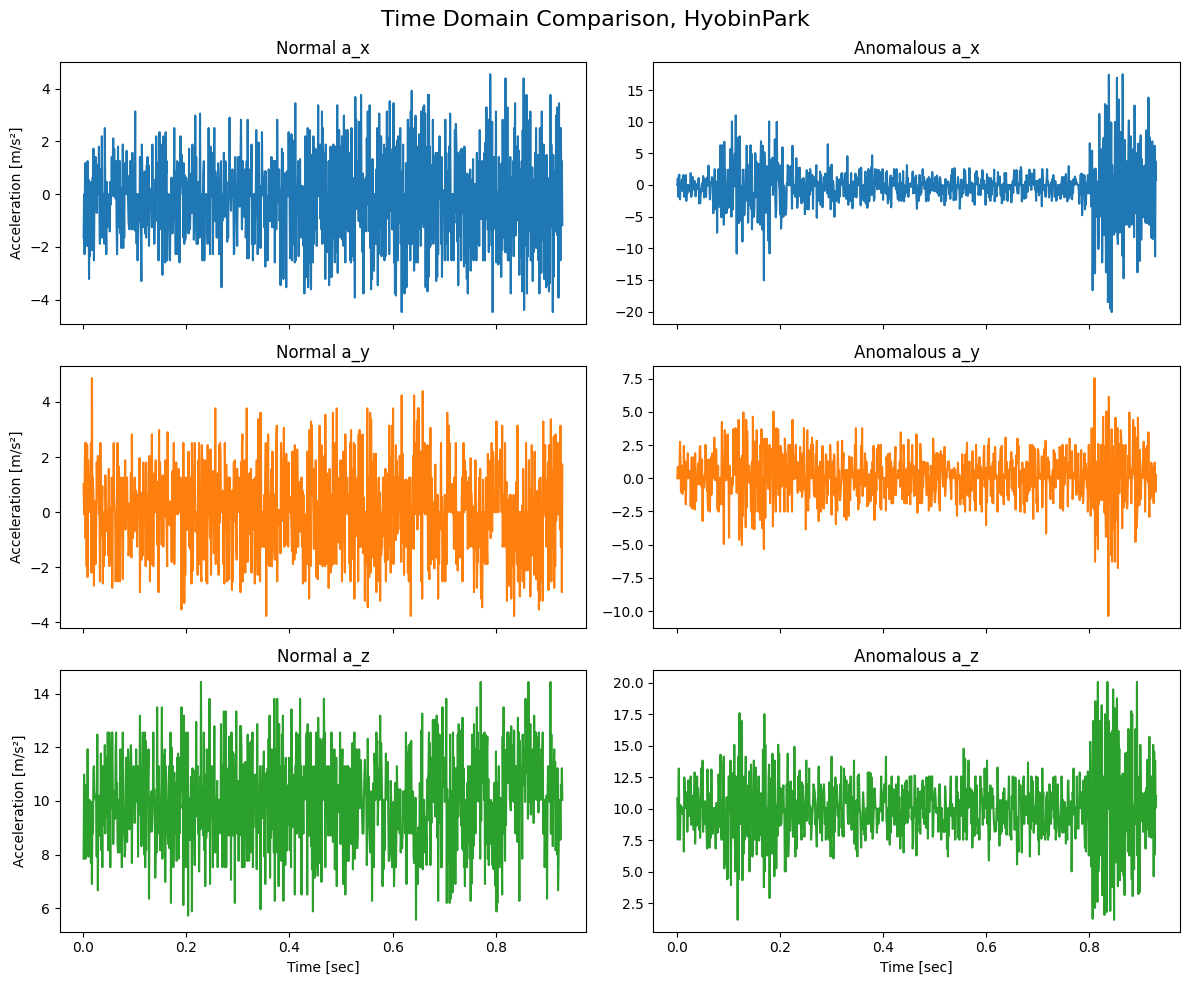

In [18]:
my_name = "HyobinPark"

# 3.4-1. Time-Domain Comparison
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex='col')
fig.suptitle(f'Time Domain Comparison, {my_name}', fontsize=16)

# Column 1: Normal Data
axes[0, 0].plot(t_norm, a_x_norm, 'tab:blue')
axes[0, 0].set_title('Normal a_x')
axes[0, 0].set_ylabel('Acceleration [m/s²]')

axes[1, 0].plot(t_norm, a_y_norm, 'tab:orange')
axes[1, 0].set_title('Normal a_y')
axes[1, 0].set_ylabel('Acceleration [m/s²]')

axes[2, 0].plot(t_norm, a_z_norm, 'tab:green')
axes[2, 0].set_title('Normal a_z')
axes[2, 0].set_ylabel('Acceleration [m/s²]')
axes[2, 0].set_xlabel('Time [sec]')

# Column 2: Anomalous Data
axes[0, 1].plot(t_anom, a_x_anom, 'tab:blue')
axes[0, 1].set_title('Anomalous a_x')

axes[1, 1].plot(t_anom, a_y_anom, 'tab:orange')
axes[1, 1].set_title('Anomalous a_y')

axes[2, 1].plot(t_anom, a_z_anom, 'tab:green')
axes[2, 1].set_title('Anomalous a_z')
axes[2, 1].set_xlabel('Time [sec]')

plt.tight_layout()
plt.show()


### Compare data of two conditions (normal vs. anomalous) of the axial flow fan.
  



#### 1) What contrast could be made between comparing time-domain characteristics of normal vs anomalous condition data?
---

Wirte down answer here.

---

#### 2) What are the main frequencies and FFT magnitudes of each measurement?
---

Wirte down answer here.

---

#### 3) Which domain features are better to detect the abnormal condition of the fan? Explain why.
---

Wirte down answer here.

---

#### 4) From the three measured dimensions, Which dimension shows the best salient feature in order to detect vibration? Explain why.
---

Wirte down answer here.

---

## Lab2 Summary and Deliverables

Answer the following questions for your achievements




### Q1. Please summarize Lab2.

---

Write down A1 here.

---


### Q2. What skills did you have to develop to accomplish this project?

---

Write down A2 here.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

Write down A3 here.

---

### Q4. What challenges did you encounter in completing the project?

---

Write down A4 here.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

Write down A5 here.

---

<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)